Machine Learning Model Parameters:
Amplitude: 0.4782
Frequency: 0.9990
Phase: -1.5630
Decay Rate: -0.0001
Offset: 0.4992


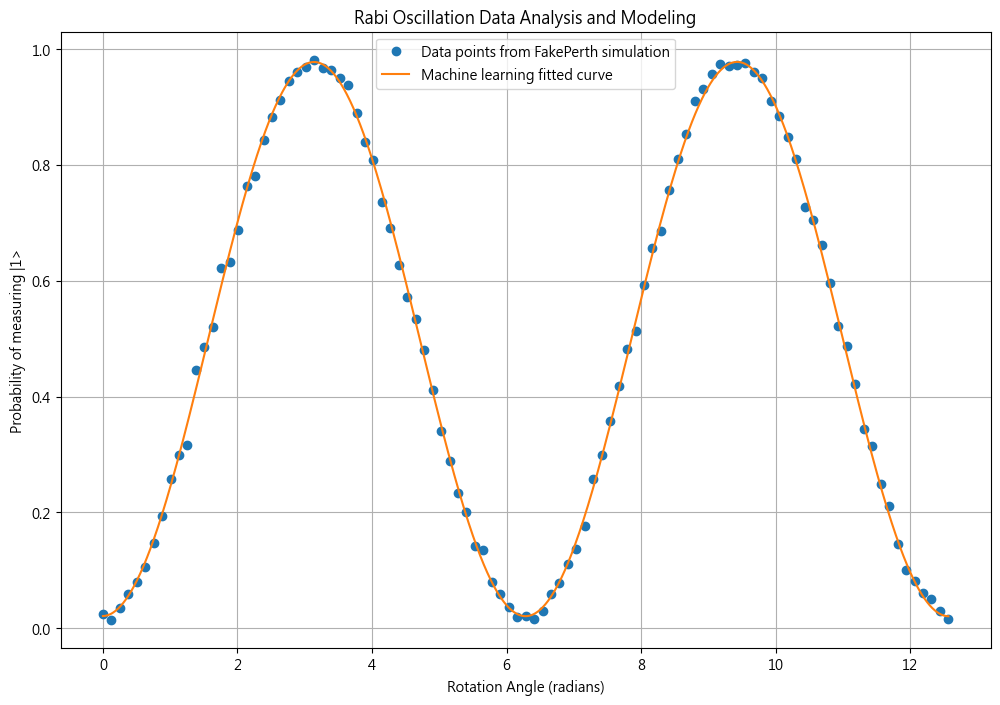

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Import the latest Qiskit modules
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime.fake_provider import FakePerth
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Resolve the matplotlib Chinese font issue
import matplotlib.font_manager as fm
# Set a common Chinese font, for example, 'Microsoft JhengHei'
plt.rcParams['font.family'] = 'Microsoft JhengHei'

# 1. Generate noisy data
# ----------------------------------------------------
# This code generates data with hardware-like noise from FakePerth
angles = np.linspace(0, 4 * np.pi, 101)
qubit = 0

backend = AerSimulator.from_backend(FakePerth())

circuits = []
for angle in angles:
    qc = QuantumCircuit(1, 1)
    qc.rx(angle, qubit)
    qc.measure(qubit, 0)
    circuits.append(qc)

job = backend.run(transpile(circuits, backend), shots=1024)
result = job.result()

prob_1s_noisy = []
for circuit in circuits:
    counts = result.get_counts(circuit)
    prob_1 = counts.get('1', 0) / 1024
    prob_1s_noisy.append(prob_1)

# 2. Define the machine learning model (decaying sinusoid)
# ----------------------------------------------------
def decaying_sinusoid(x, amplitude, frequency, phase, decay, offset):
    """
    A mathematical model to fit the Rabi oscillation.
    This function is the core of the machine learning model.
    """
    return amplitude * np.sin(frequency * x + phase) * np.exp(-x * decay) + offset

# 3. Perform regression analysis to learn model parameters
# ----------------------------------------------------
# Use curve_fit to fit the data
# p0 is the initial guess for the parameters, which helps the model converge faster
popt, pcov = curve_fit(
    decaying_sinusoid, 
    angles, 
    prob_1s_noisy, 
    p0=[0.5, 1, 0, 0.1, 0.5]
)

# Get the best-fit parameters
amplitude_fit, frequency_fit, phase_fit, decay_fit, offset_fit = popt

print("Machine Learning Model Parameters:")
print(f"Amplitude: {amplitude_fit:.4f}")
print(f"Frequency: {frequency_fit:.4f}")
print(f"Phase: {phase_fit:.4f}")
print(f"Decay Rate: {decay_fit:.4f}")
print(f"Offset: {offset_fit:.4f}")

# 4. Plot the results
# ----------------------------------------------------
plt.figure(figsize=(12, 8))
plt.plot(angles, prob_1s_noisy, 'o', label='Data points from FakePerth simulation')

# Use the machine learning model to plot a smooth fitted curve
x_fit = np.linspace(0, max(angles), 1000)
y_fit = decaying_sinusoid(x_fit, *popt)
plt.plot(x_fit, y_fit, '-', label='Machine learning fitted curve')

plt.title('Rabi Oscillation Data Analysis and Modeling')
plt.xlabel('Rotation Angle (radians)')
plt.ylabel('Probability of measuring |1>')
plt.legend()
plt.grid(True)
plt.show()